# Trained window-representation evaluation
Image-only shared-region diagnosis using the checkpoint's saved model, geometry and split IDs. No training or checkpoint edits.
Start with the configuration below, then **Run All**. Install Jupyter/IPython in your evaluation environment if needed; the project dependencies supply PyTorch, NumPy, Pillow, matplotlib, pandas, sklearn and tqdm.

The shipped example checkpoint has 198 test lines but **zero original manifest pairs with both sides in test**. That is a pair-eligibility limitation, not evidence of success/failure. Positive figures, AUC and retrieval remain unavailable when the saved population cannot support them. Constructed negatives are explicitly **presumed unrelated**, not verified ground truth.

In [12]:
# All user-adjustable settings (paths are relative to the repository root).
CHECKPOINT = "Weights/real_20260924_222148/checkpoint_best.pt"
DATASET = "DataSet/ArabicDataset"
SPLIT = "test"                      # train / val / test; always uses saved membership
NUM_SAMPLES = 5                     # controls BOTH random qualitative sections
RANDOM_SEED = 42
DEVICE = "mps"                     # evaluation-only CPU fallback when CUDA unavailable
REPRESENTATION = "fused"            # local / context / fused

SIMILARITY_THRESHOLD = 0.60         # uncalibrated starting values, NOT probabilities
SCORE_MODE = "background"           # background or raw (C - threshold)
CONTRAST_MARGIN = 0.05
MIN_REGION_WINDOWS = 5             # set 4 explicitly for comparison
MAX_INTERNAL_GAP = 1               # 0 = strict consecutive supported windows
GAP_OPEN = 0.20
GAP_EXTEND = 0.05
MAX_ALIGNMENT_CANDIDATES = 128      # existing greedy-search budget; limit is reported
PAIR_DECISION_THRESHOLD = None     # only a previously fixed validation threshold
TOP_K = 5                          # best/worst table size

CONSTRUCT_NEGATIVES_IF_MISSING = True
CONSTRUCTED_NEGATIVE_COUNT = None  # default: one sampled presumed pair per test line
ANNOTATION_MANIFEST = None         # optional pair mask paths / aligned intervals JSONL
RUN_FULL_QUANTITATIVE = True
MAX_PAIRS = 0                      # 0 = all eligible pairs incl. declared constructed sample
RUN_RETRIEVAL = True
RETRIEVAL_NEGATIVES = 20
RETRIEVAL_MAX_QUERIES = 0           # 0 = all eligible test queries
RUN_REPRESENTATION_COMPARISON = True
RUN_FEATURE_DIAGNOSTICS = True
FEATURE_MAX_LINES = 100
FEATURE_MAX_WINDOWS = 1024
SHOW_FAILURE_FIGURES = False       # can be verbose; uses the SAME comprehensive plot
RUN_TEXT_DTW_DIAGNOSTIC = False     # supervised diagnostic, never used for image masks

SAVE_RESULTS = True
SAVE_FIGURES = True
RESULTS_ROOT = "Results/Evaluation" # unique subdirectory each run; nothing overwritten

## 1. Imports and checkpoint loading
Run from the repository or its `notebooks/` directory. The helper reuses `train.load_checkpoint`, `train.build_loaders`, `dataset.prepare_image`, `model.extract_windows`, and the existing `evaluate.py` matcher/mask geometry. No independent reconstruction of the CNN, Transformer, fusion, crop or normalization.

In [13]:
from pathlib import Path
import sys, json, hashlib
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "model.py").is_file() and (p / "evaluate.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter from AlignmentProject or its notebooks/ directory.")
sys.path.insert(0, str(ROOT))
# Reload project modules so an already-running kernel sees source fixes.
for module_name in ("evaluation_utils", "train", "dataloader", "dataset"):
    sys.modules.pop(module_name, None)
from evaluation_utils import (
    EvaluationSession, sample_random_pairs, plot_pair_alignment,
    plot_representation_comparison, evaluate_population, plot_distributions,
    discrimination_metrics, retrieval_metrics, feature_diagnostics,
    aggregate_summary, failure_tables, save_results, save_pair_artifacts,
    text_dtw_diagnostic,
)
try:
    from IPython.display import display
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
except ImportError:                 # enables headless validation of these same cells
    def display(value):
        print(value if not isinstance(value, plt.Figure) else "Rendered matplotlib figure")

def project_path(value):
    if value is None:
        return None
    path = Path(value).expanduser()
    return path if path.is_absolute() else ROOT / path

SETTINGS = dict(threshold=SIMILARITY_THRESHOLD, score_mode=SCORE_MODE,
                contrast_margin=CONTRAST_MARGIN, min_windows=MIN_REGION_WINDOWS,
                max_gap=MAX_INTERNAL_GAP, gap_open=GAP_OPEN, gap_extend=GAP_EXTEND,
                max_candidates=MAX_ALIGNMENT_CANDIDATES)
session = EvaluationSession(
    project_path(CHECKPOINT), project_path(DATASET), split=SPLIT, device=DEVICE,
    seed=RANDOM_SEED, settings=SETTINGS,
    construct_negatives=CONSTRUCT_NEGATIVES_IF_MISSING,
    negative_count=CONSTRUCTED_NEGATIVE_COUNT,
    annotation_manifest=project_path(ANNOTATION_MANIFEST),
)
information = session.summary()
print("Representation:", REPRESENTATION)
print("Alignment settings:", SETTINGS)
print("Inference: eval mode, no gradients, no augmentation; float32 visual inference.")
print("Checkpoint selection metric:", session.saved.get("selection_metric"))

/Users/ahmedmas/Desktop/AlignmentProject/train.py:243: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved = torch.load(path,map_location='cpu')


CHECKPOINT
Path: /Users/ahmedmas/Desktop/AlignmentProject/Weights/real_20260924_222148/checkpoint_best.pt
SHA256: 397e36722cbfdac8319f1850a5a0fa7ddc5521498ffef538c8bc6a231dd62acc
Epoch: 20
Best validation loss: 1.1180943248943351
Architecture: simple-alignment-core
CNN: resnet18
Transformer: tiny
Embedding dimension: 128
Transformer layers: 5
Heads: 1
Window width: 32
Window stride: 16
Image size: 128x1024
RTL: True
Parameter count: 12260672
Device: mps
Crop: auto
Grayscale: True
Binarize: False
Split manifest SHA256: f03654ea952a534d1eef1bd3cdc2fef2adc88d4b753a1767fb8f901b6da2d890
EVALUATION DATASET
Path: /Users/ahmedmas/Desktop/AlignmentProject/DataSet/ArabicDataset
Dataset type: real
Split: test
Number of samples: 198
Eligible pairs: 198
Number of aligned pairs: 0
Number of unaligned pairs: 198
Constructed negatives: 198
Unknown labels: {}
Excluded pairs outside split: 3825
Ground truth masks available: 0
Ground truth aligned intervals available: 0
Saved split sizes: {'train': 1698,

## 2. Population, labels and alignment contract
Pairs are recovered from the existing paired dataset view, then **both sides** must match saved split members, including crop identity. The paired view does not regenerate a split. Independent-line training records can lose pair labels through deduplication; they are not used as pair labels here.

The inspected real manifest uses `high_match`, `medium_match`, `low_match` as positive labels and `no_shared_content` as negative. These are dataset labels (derived using annotation/text heuristics), not independently verified character alignments. Unknown labels remain unknown. A synthetic filename pair alone is not automatically labelled positive.

If no eligible provided negatives exist, only the **test** split may supply seeded cross-group presumed negatives. Known pair/anchor/group associations and known positives are excluded. Remaining unannotated shared content is possible; constructed results are reported separately.

The existing affine-gap Smith–Waterman allows local starts/ends on both lines. Global Needleman–Wunsch forces whole-line alignment; standard subsequence DTW matches one whole query. We keep the existing greedy noncrossing, non-reusing multi-region matcher. It is not globally optimal and one-to-one diagonal matches plus gaps may handle width variation poorly; local DTW would be a later controlled comparison.

Background reward = cosine − max(threshold, row median + margin, column median + margin).
Raw mode = cosine − threshold. No image-to-text DTW position prior is added.
Background subtraction may suppress broad/repeated genuine matches. Five distinct positively supported physical windows per side are required by default. Gap transitions do not count as support. Only bounded internal gaps may fill; no unsupported prefix/suffix.

**Pair score = maximum accepted region's existing affine reward objective; zero when no region is accepted.** It is length dependent, not calibrated confidence. Off-path similarity excludes accepted anchor cells only; it is not guaranteed nonmatching ground truth. Path length counts positive anchors. Horizontal/vertical jumps count index gaps between accepted anchors within a region, not exact traceback gap transitions; between-region discontinuities are separate. Configure thresholds on validation, then freeze them before test.

In [14]:
print("Eligible label counts:")
display(pd.Series([p["label"] for p in session.pairs], dtype="object").value_counts(dropna=False))
print("Saved line split sizes:", session.split_sizes)
if not any(p["target"] == 1 for p in session.pairs):
    print("No eligible labelled positive pair: aligned figures/AUC/retrieval may be unavailable.")
print("Provided negatives:", session.provided_negative_count)
print("Constructed negatives:", sum(p["constructed_negative"] for p in session.pairs))
if SPLIT != "test":
    print("This is an explicit", SPLIT, "diagnostic; it is NOT held-out test performance.")

Eligible label counts:


constructed_negative    198
Name: count, dtype: int64

Saved line split sizes: {'train': 1698, 'val': 176, 'test': 198}
No eligible labelled positive pair: aligned figures/AUC/retrieval may be unavailable.
Provided negatives: 0
Constructed negatives: 198


## 3. Reproducible qualitative selection
Both sections use `NUM_SAMPLES`. IDs are selected randomly with a dedicated seeded generator; fewer are shown only when the population is smaller. Prediction never sees the label, transcript or ground-truth mask.

In [15]:
aligned_samples = sample_random_pairs(session.pairs, NUM_SAMPLES, aligned=True, seed=RANDOM_SEED)
unaligned_samples = sample_random_pairs(session.pairs, NUM_SAMPLES, aligned=False, seed=RANDOM_SEED)
print("Random aligned IDs:", [p["sample_id"] for p in aligned_samples])
print("Random unaligned IDs:", [p["sample_id"] for p in unaligned_samples])
qualitative_results = {}
def show_pairs(pairs):
    if not pairs:
        print("No eligible examples in the saved split.")
    for pair in pairs:
        result = session.evaluate_pair(pair, REPRESENTATION)
        qualitative_results[pair["sample_id"]] = result
        fig = plot_pair_alignment(session, result)
        display(fig)
        plt.close(fig)
        display(pd.Series(result["metrics"], name=pair["sample_id"]))
        print("Rejected candidate reason counts:", dict(Counter(r["reason"] for r in result["match"]["rejected"])))
        print("Annotation provenance:", pair["annotation_provenance"])
        if all(gt is None for gt in result["ground_truth"]):
            print("Ground-truth localization metrics unavailable for this dataset.")

Random aligned IDs: []
Random unaligned IDs: ['constructed:d51b4c88bd4c11460855', 'constructed:26b50321791e5c905450', 'constructed:078593eddf02a40a4e7d', 'constructed:f6326dadc5b14c8831e6', 'constructed:55d1af8baa9c21897a39']


## A. RANDOM ALIGNED SAMPLES
Full-width originals, exact model inputs with physical window boundaries, extracted-window strips, raw cosine (fixed −1…1), separate reward heatmap, accepted correspondences, binary source masks, overlays and score panel. Logical window 0 is rightmost under RTL. Source masks use inverse crop/resize geometry, not a source-pixel 32/16 grid.

In [16]:
show_pairs(aligned_samples)

No eligible examples in the saved split.


## B. RANDOM UNALIGNED SAMPLES
The exact same predictor is used. Labels never hide a prediction. A large predicted region on a **verified** negative is a false positive; on a constructed negative it is suspicious and requires review.

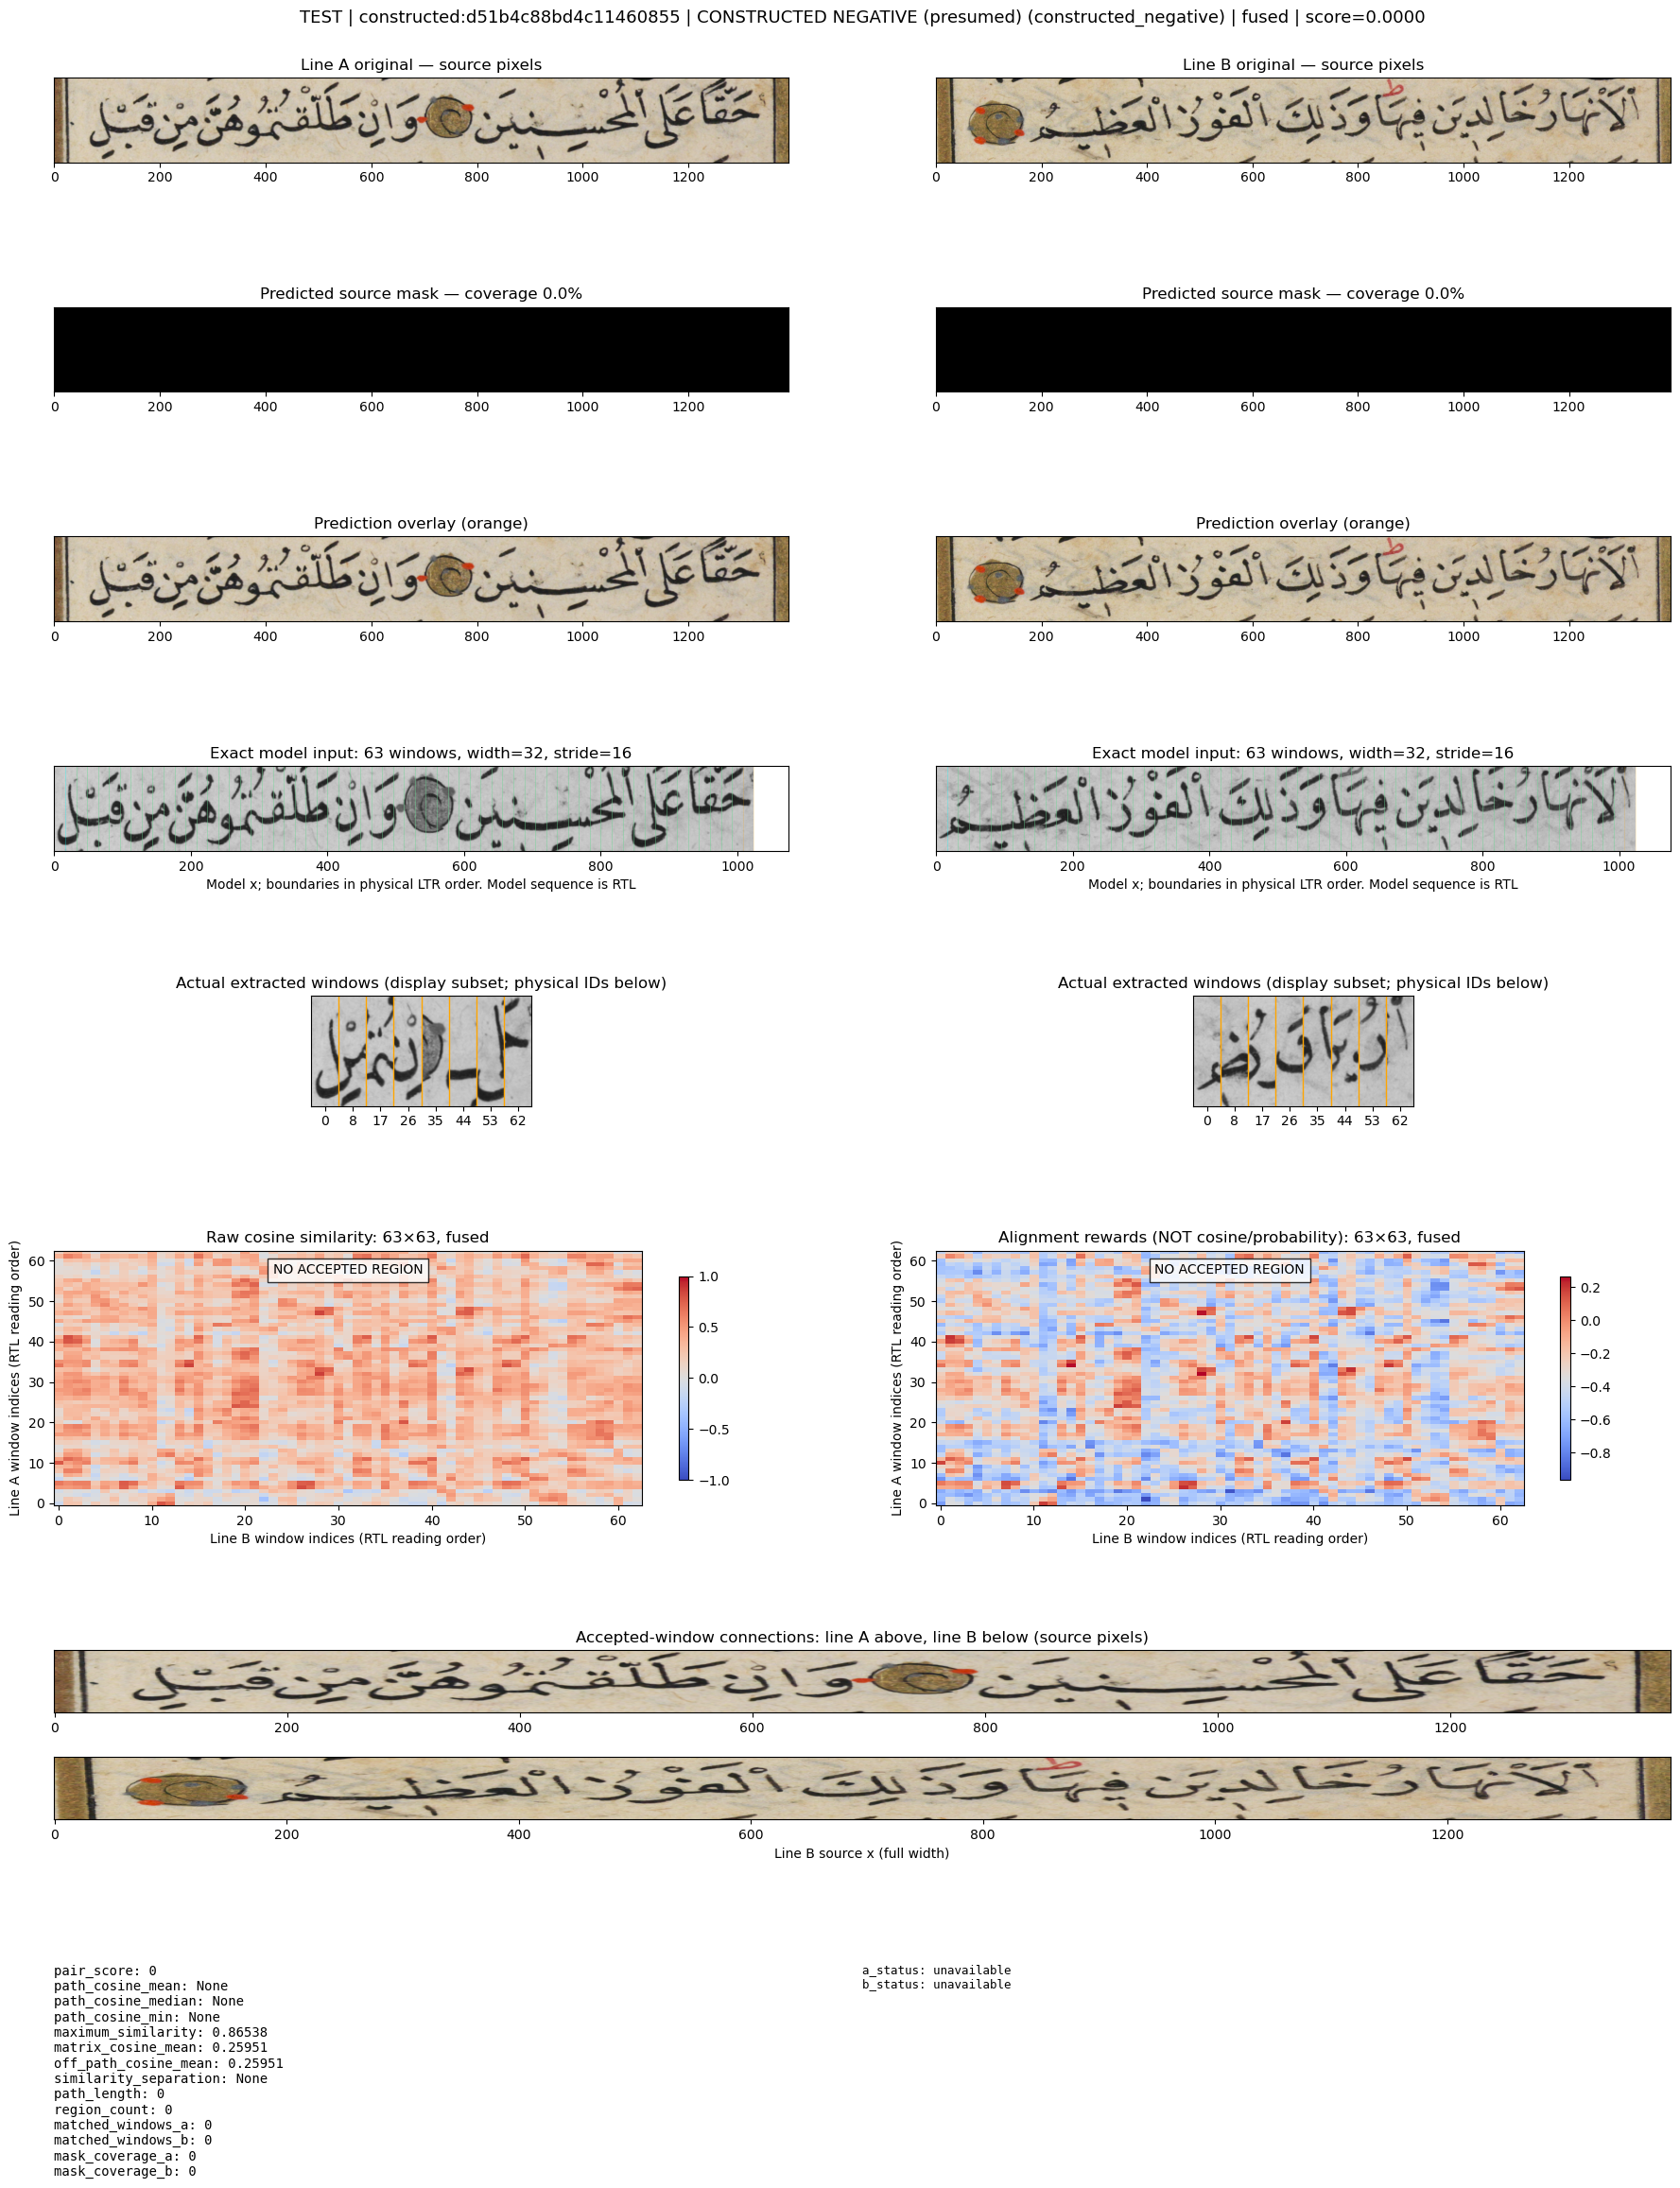

sample_id                                      constructed:d51b4c88bd4c11460855
label                                                      constructed_negative
target                                                                        0
split                                                                      test
image_a                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
image_b                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
annotation_provenance                                                      none
constructed_negative                                                       True
representation                                                            fused
pair_score                                                                  0.0
accepted_region_score_sum                                                     0
max_local_alignment_score                                              0.412197
path_length                             

Rejected candidate reason counts: {'insufficient_positive_support': 128, 'candidate_limit_reached': 1}
Annotation provenance: none
Ground-truth localization metrics unavailable for this dataset.


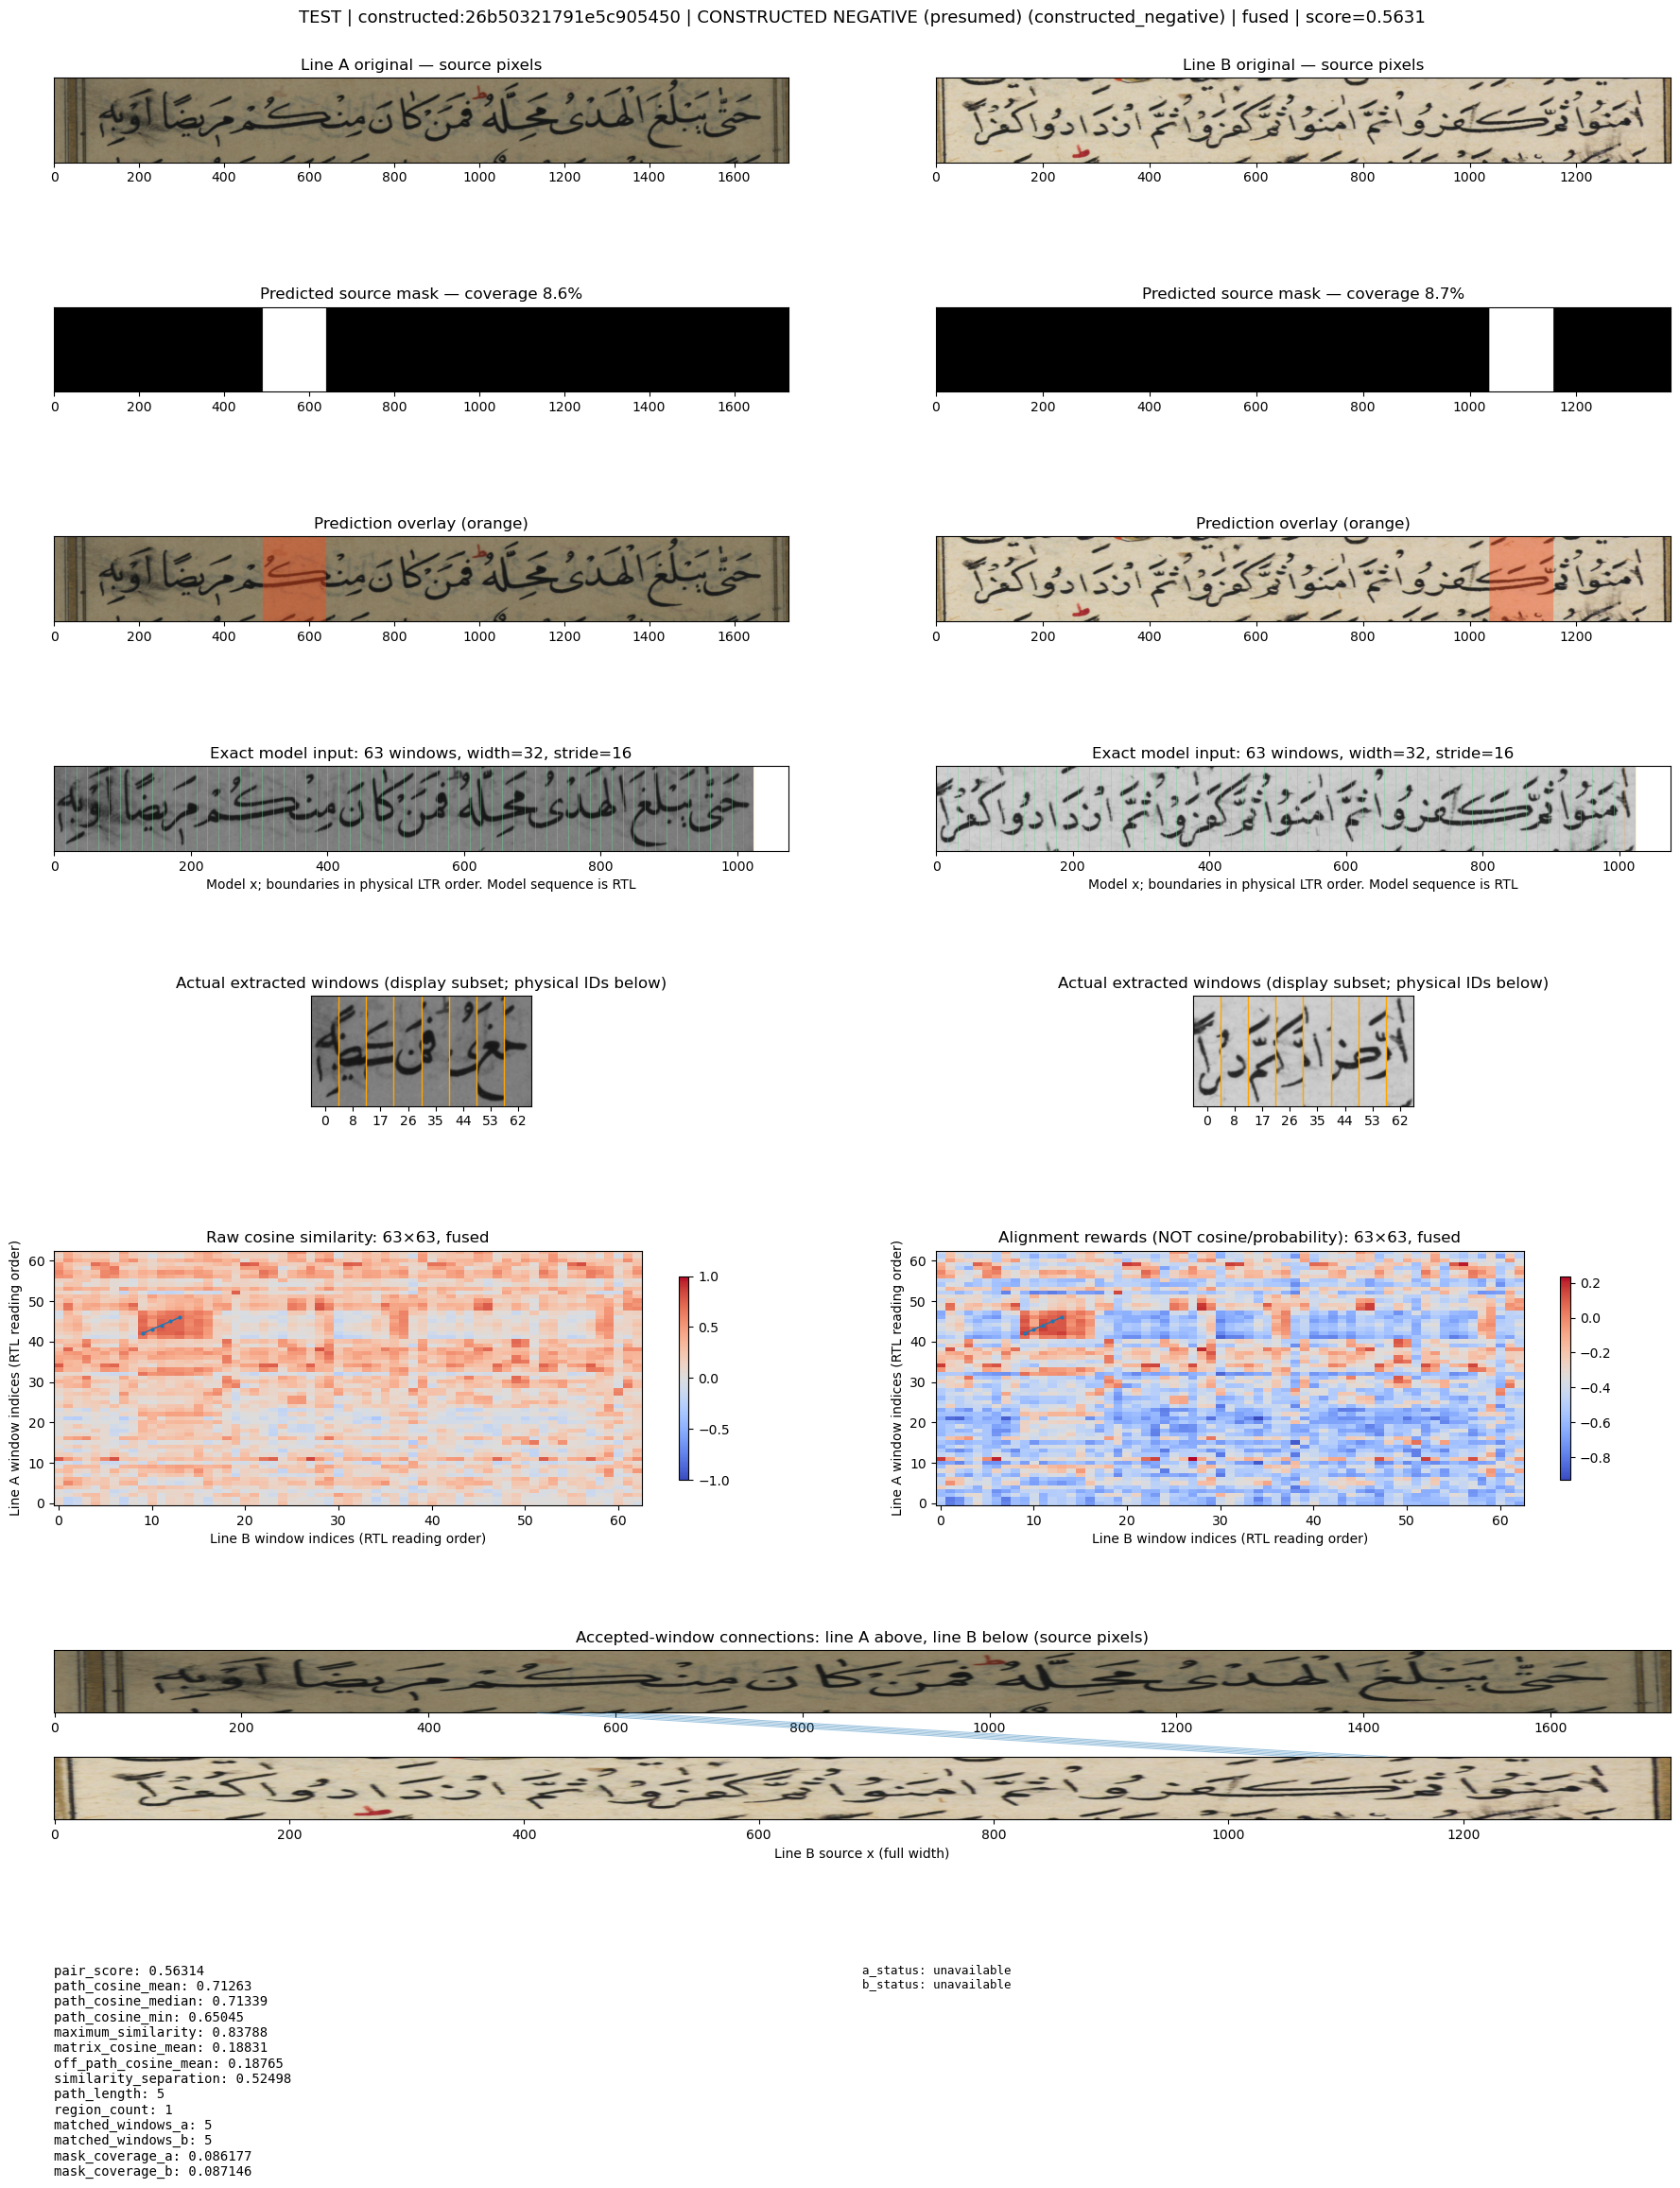

sample_id                                      constructed:26b50321791e5c905450
label                                                      constructed_negative
target                                                                        0
split                                                                      test
image_a                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
image_b                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
annotation_provenance                                                      none
constructed_negative                                                       True
representation                                                            fused
pair_score                                                             0.563143
accepted_region_score_sum                                              0.563143
max_local_alignment_score                                              0.563143
path_length                             

Rejected candidate reason counts: {'insufficient_positive_support': 35}
Annotation provenance: none
Ground-truth localization metrics unavailable for this dataset.


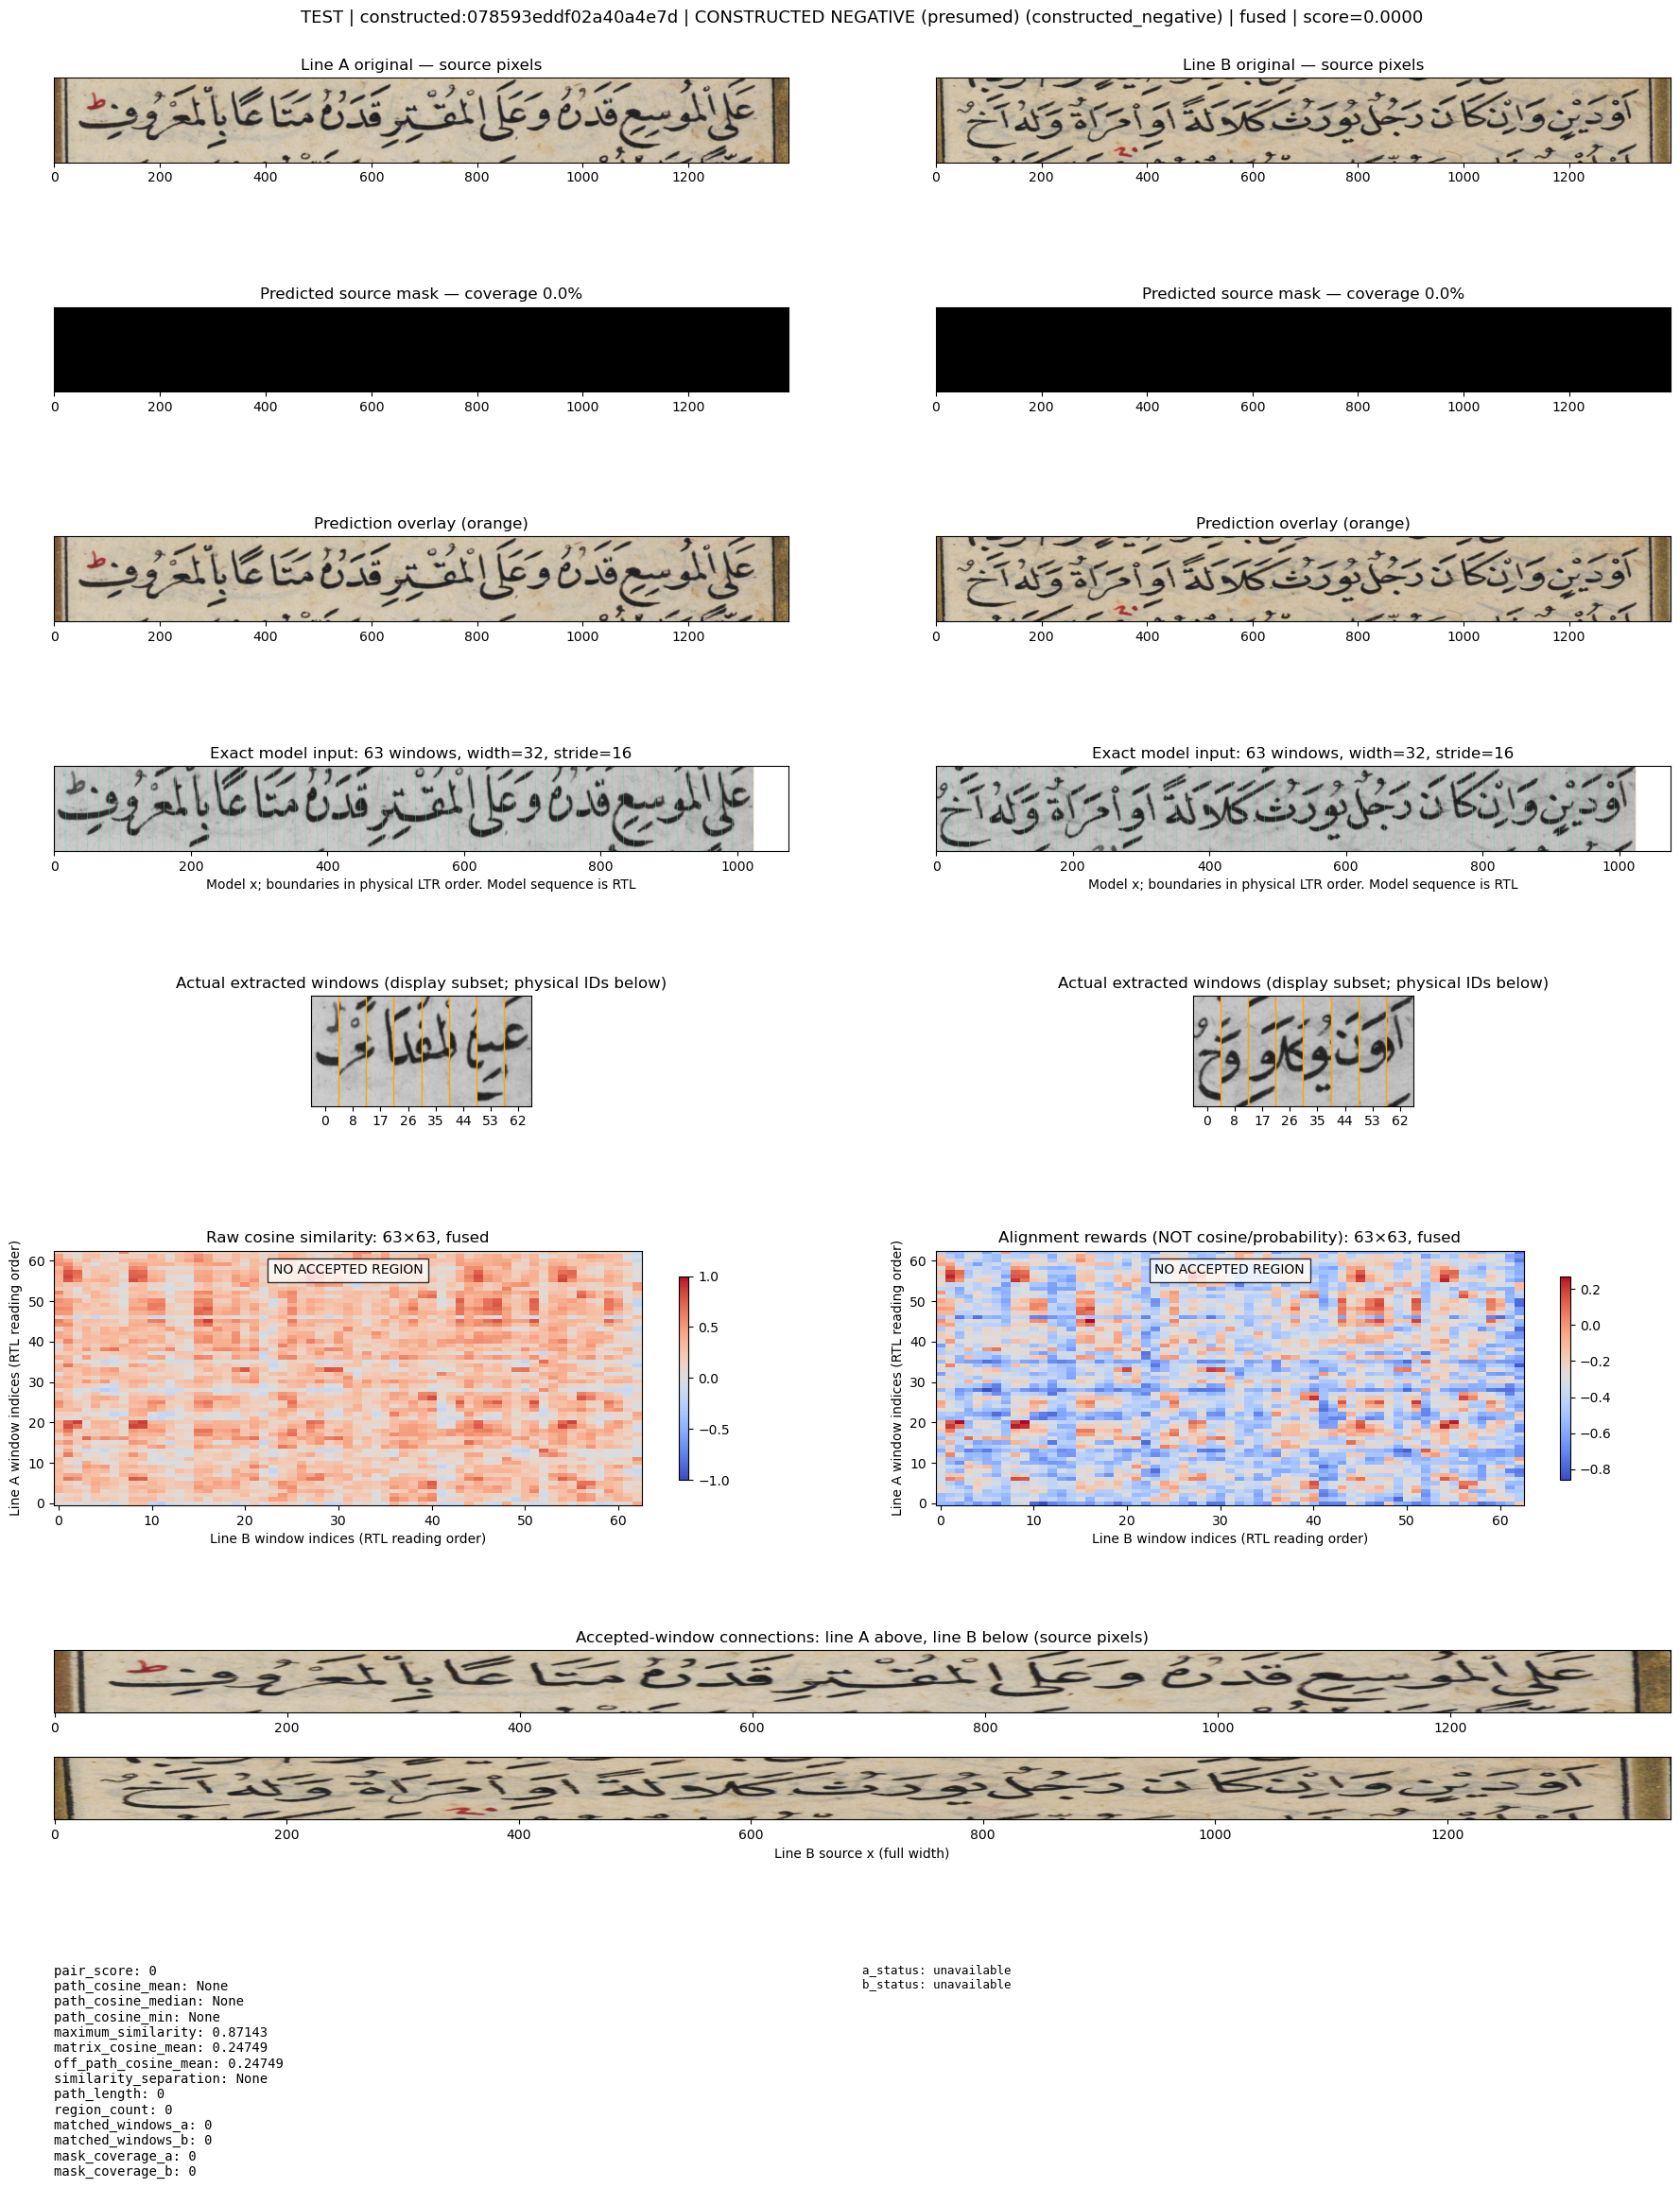

sample_id                                      constructed:078593eddf02a40a4e7d
label                                                      constructed_negative
target                                                                        0
split                                                                      test
image_a                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
image_b                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
annotation_provenance                                                      none
constructed_negative                                                       True
representation                                                            fused
pair_score                                                                  0.0
accepted_region_score_sum                                                     0
max_local_alignment_score                                              0.517881
path_length                             

Rejected candidate reason counts: {'insufficient_positive_support': 119}
Annotation provenance: none
Ground-truth localization metrics unavailable for this dataset.


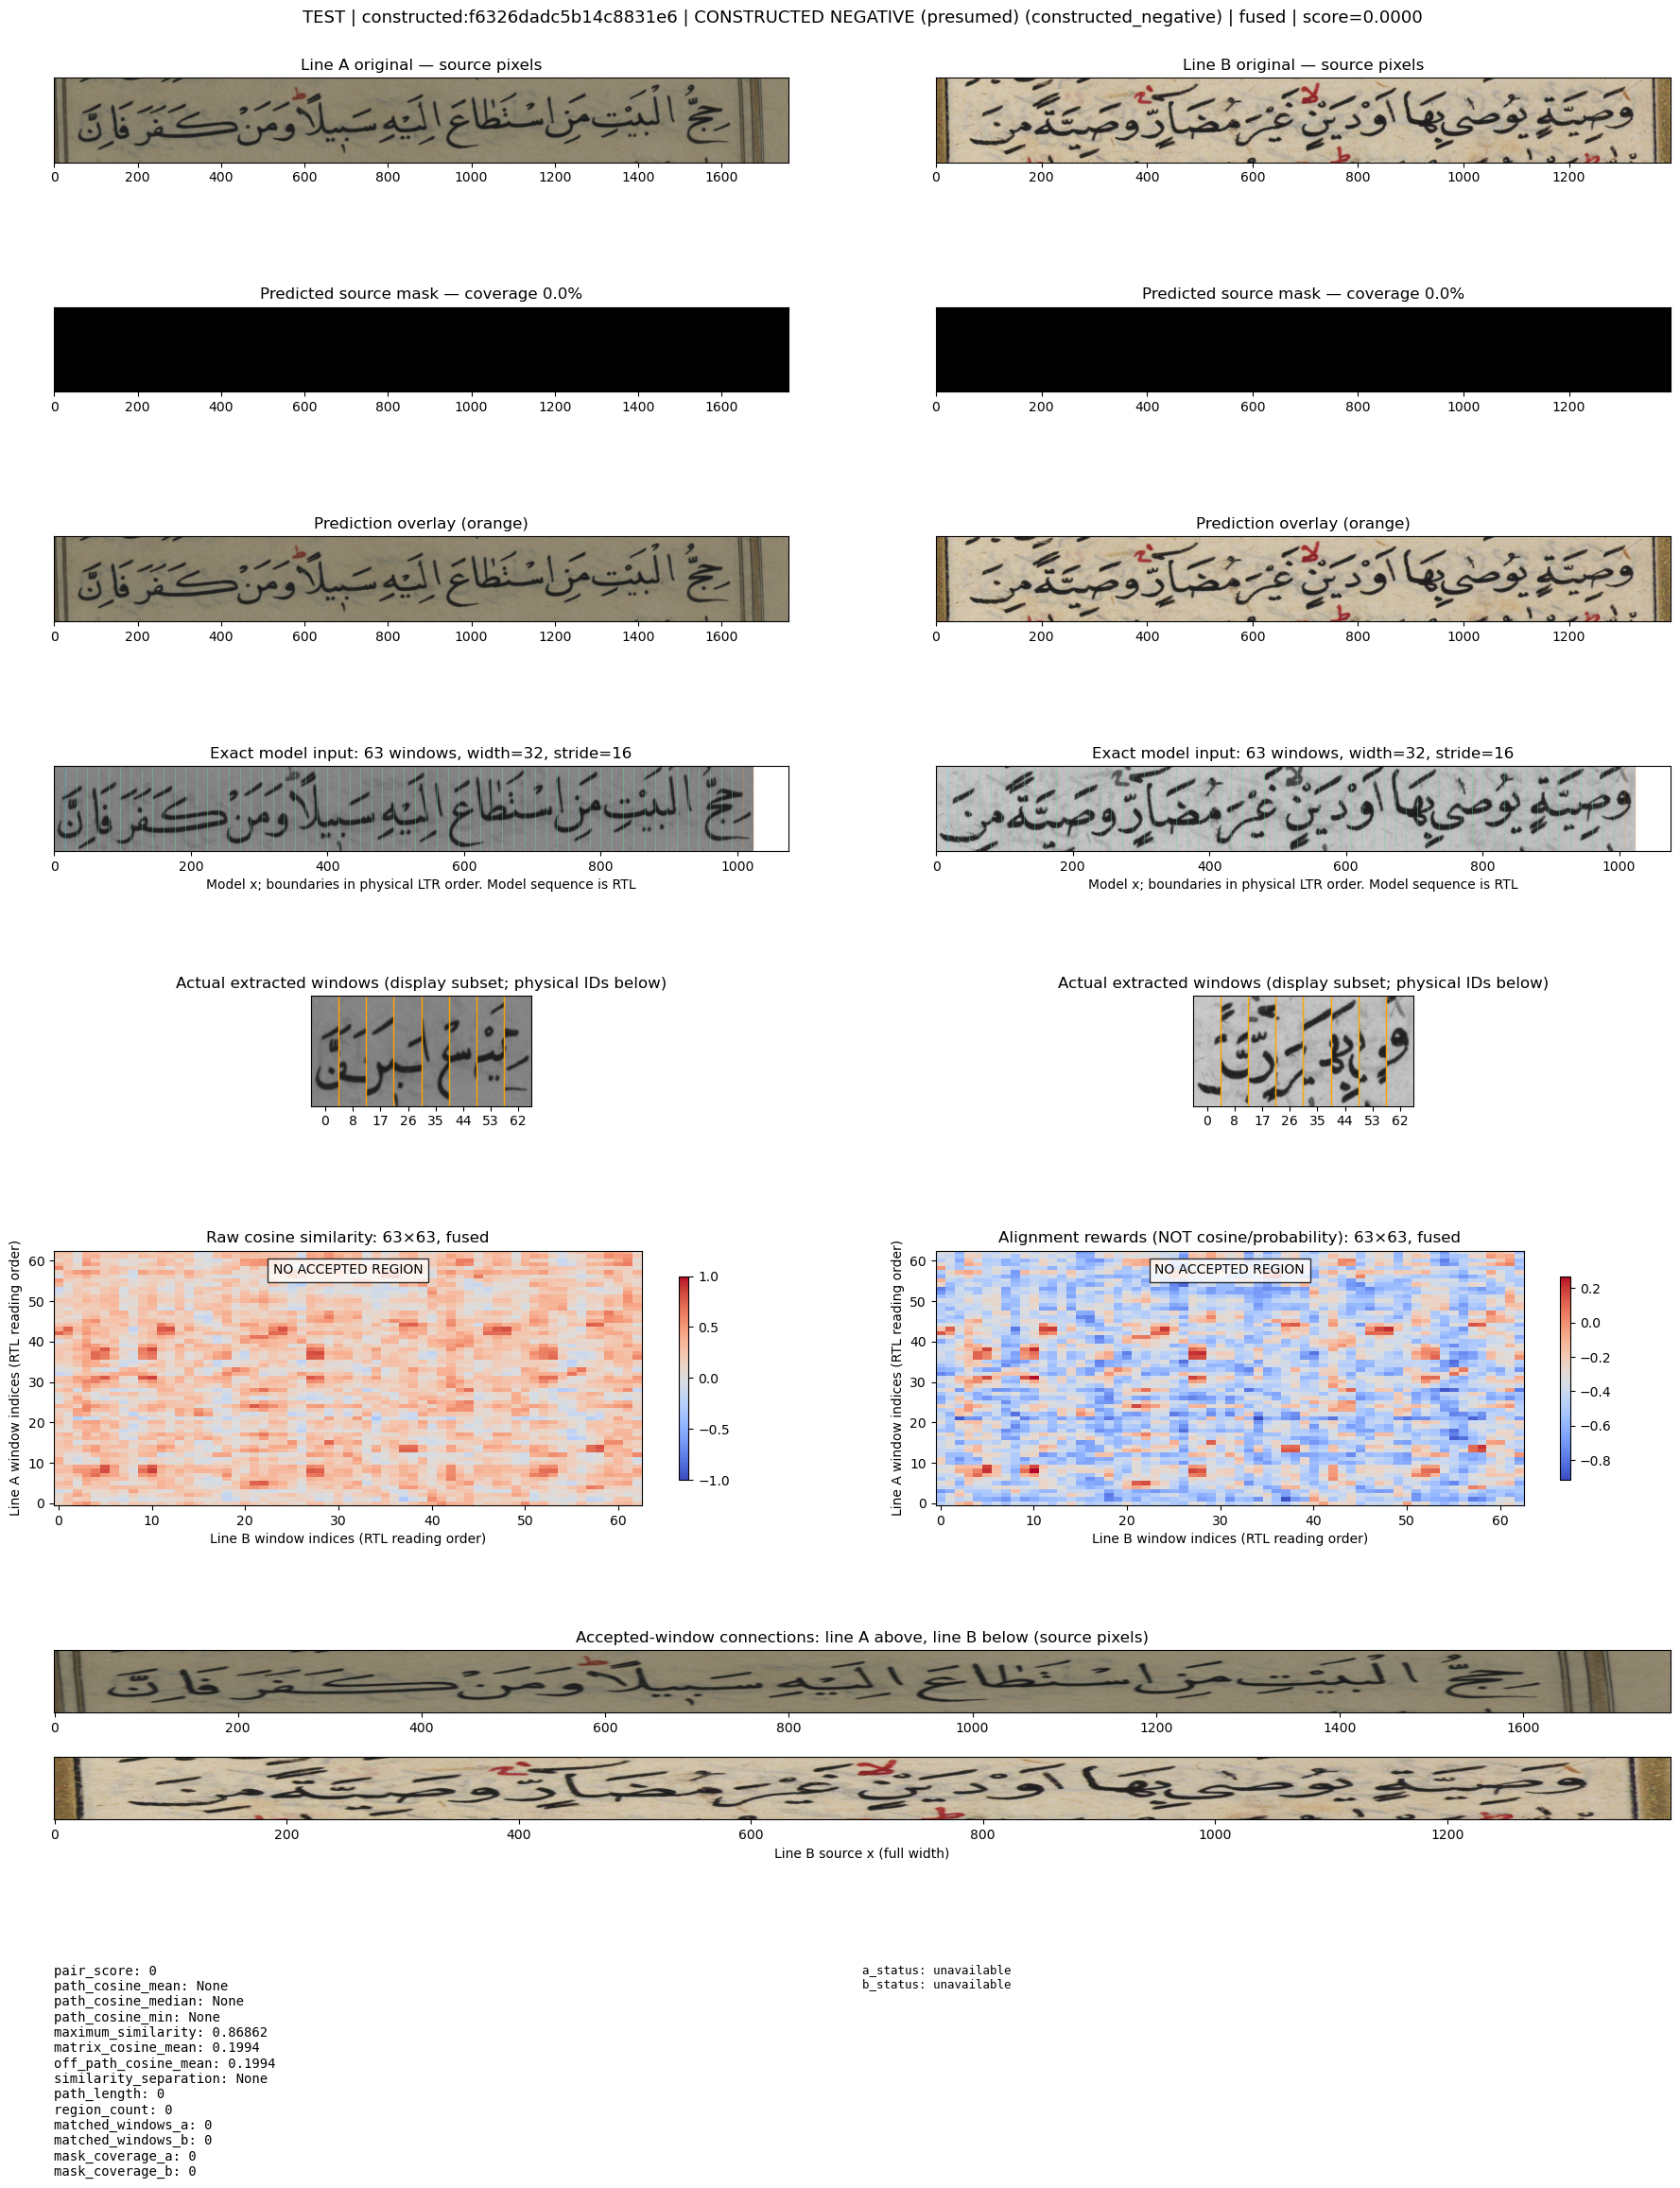

sample_id                                      constructed:f6326dadc5b14c8831e6
label                                                      constructed_negative
target                                                                        0
split                                                                      test
image_a                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
image_b                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
annotation_provenance                                                      none
constructed_negative                                                       True
representation                                                            fused
pair_score                                                                  0.0
accepted_region_score_sum                                                     0
max_local_alignment_score                                              0.391463
path_length                             

Rejected candidate reason counts: {'insufficient_positive_support': 75}
Annotation provenance: none
Ground-truth localization metrics unavailable for this dataset.


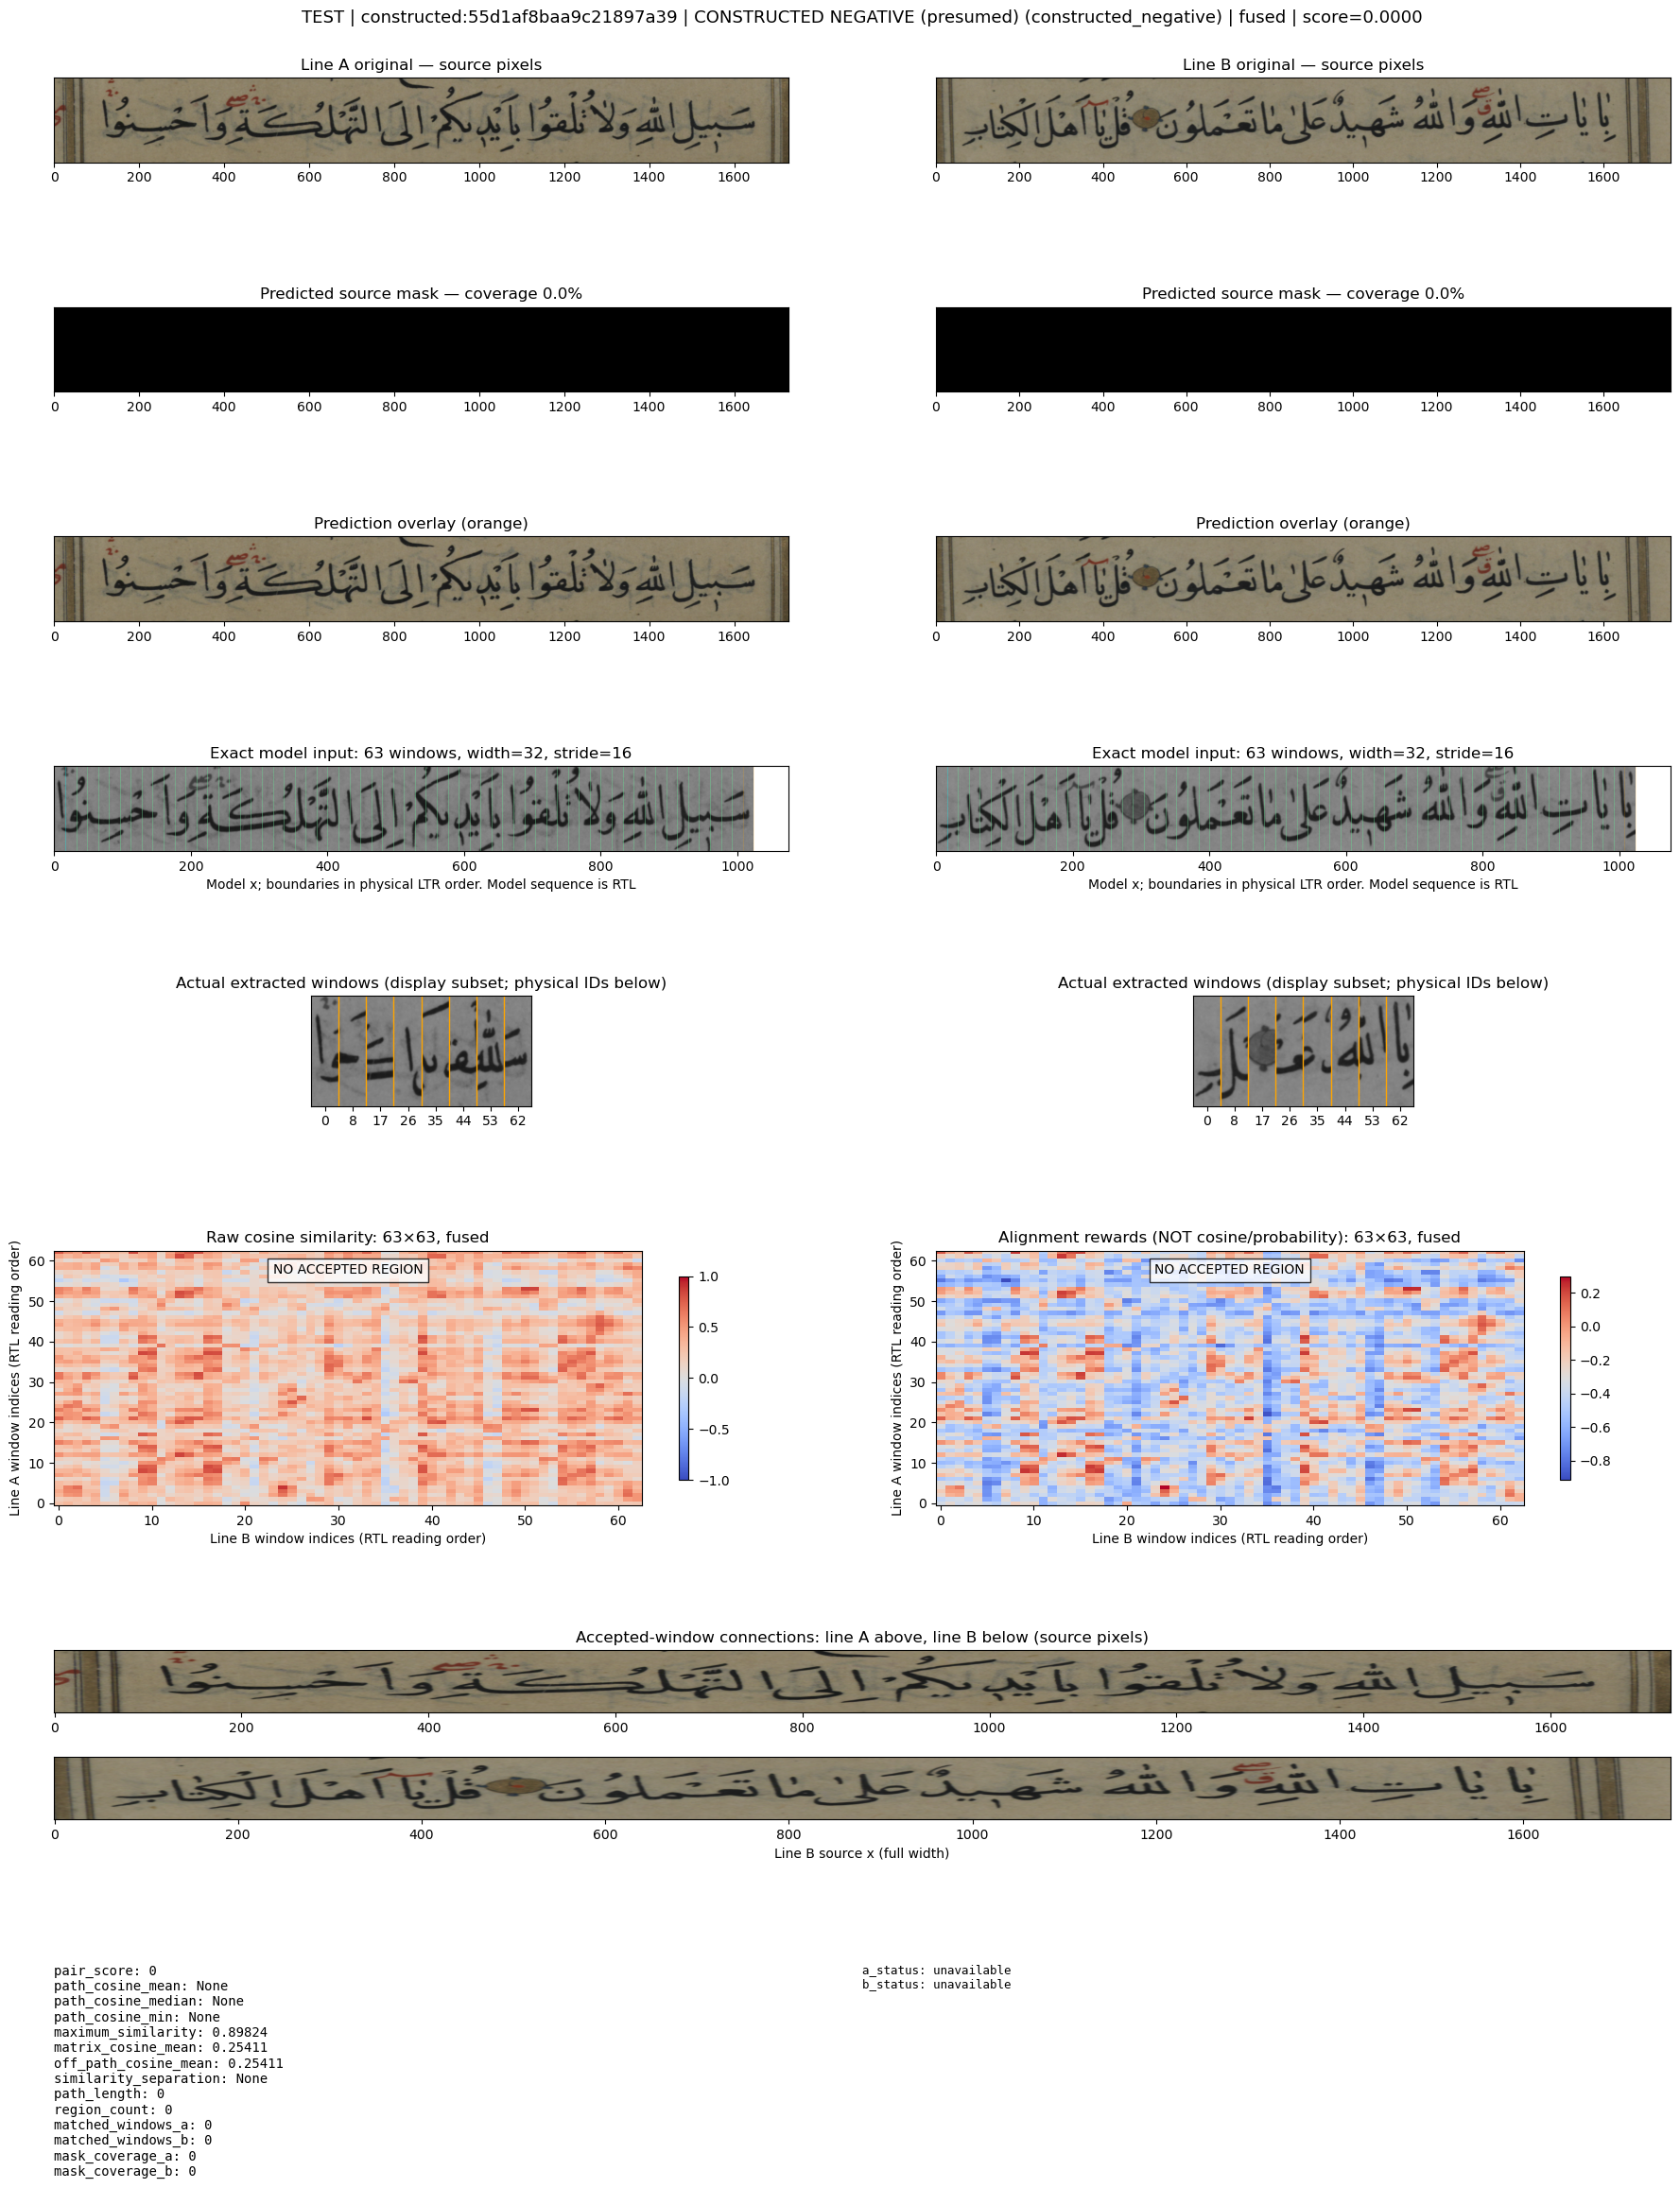

sample_id                                      constructed:55d1af8baa9c21897a39
label                                                      constructed_negative
target                                                                        0
split                                                                      test
image_a                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
image_b                       /Users/ahmedmas/Desktop/AlignmentProject/DataS...
annotation_provenance                                                      none
constructed_negative                                                       True
representation                                                            fused
pair_score                                                                  0.0
accepted_region_score_sum                                                     0
max_local_alignment_score                                              0.483162
path_length                             

Rejected candidate reason counts: {'insufficient_positive_support': 129, 'candidate_limit_reached': 1}
Annotation provenance: none
Ground-truth localization metrics unavailable for this dataset.


In [17]:
show_pairs(unaligned_samples)

## 4. Local versus context versus fused
The same selected images and checkpoint are used. Each representation is explicitly cosine-normalized by the shared cosine function. Fused remains the default. Displaying an attractive path does not establish correspondence correctness.

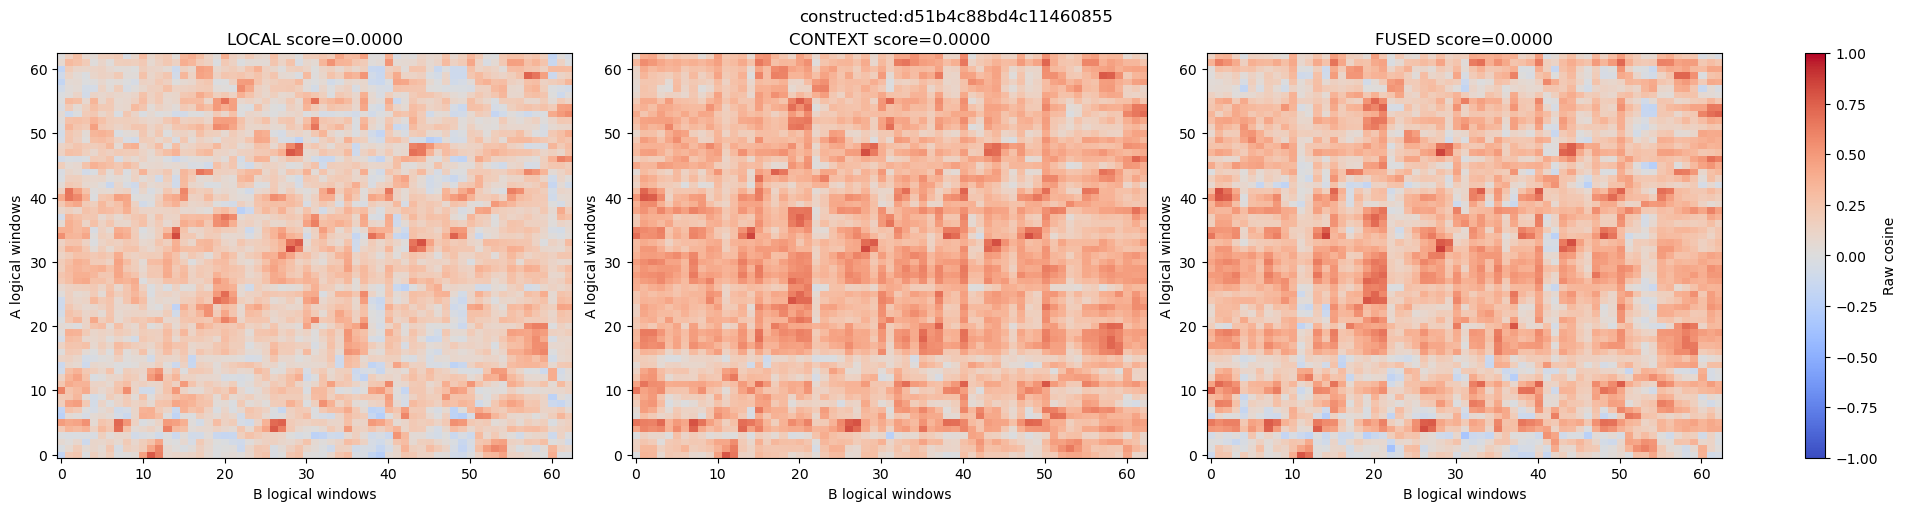

local      0.0
context    0.0
fused      0.0
Name: Best accepted local objective, dtype: float64

In [19]:
if RUN_REPRESENTATION_COMPARISON:
    for pair in aligned_samples[:1] or unaligned_samples[:1]:
        figure, scores = plot_representation_comparison(session, pair)
        display(figure); plt.close(figure)
        display(pd.Series(scores, name="Best accepted local objective"))

## 5. Quantitative saved-split evaluation
With `MAX_PAIRS=0`, score all eligible manifest pairs plus the explicitly declared constructed-negative sample. This is **not all combinatorial pairs of test lines**. Counts report available pairs, evaluated pairs and unique-line coverage. Unknown labels are excluded from discrimination. No test label is used to choose a threshold.

In [20]:
population = evaluate_population(session, REPRESENTATION, MAX_PAIRS) if RUN_FULL_QUANTITATIVE else None
if population is not None:
    display(pd.DataFrame(population["rows"]).head())
    print({k: population[k] for k in ("split", "population", "available_pairs",
                                     "evaluated_pairs", "evaluated_unique_lines", "saved_split_unique_lines")})

test pairs (fused): 100%|██████████| 198/198 [04:24<00:00,  1.33s/it]


,sample_id,label,target,split,image_a,image_b,annotation_provenance,constructed_negative,representation,pair_score,...,pixel_ranges_a,a_status,a_reason,mask_coverage_b,matched_windows_b,total_windows_b,logical_ranges_b,pixel_ranges_b,b_status,b_reason
0,constructed:8036c15d305dbff1785c,constructed_negative,0,test,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,none,True,fused,0.000000,...,[],unavailable,no pair-specific localization annotation,0.000000,0,63,[],[],unavailable,no pair-specific localization annotation
1,constructed:662c0b2a4e089011dc73,constructed_negative,0,test,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,none,True,fused,0.000000,...,[],unavailable,no pair-specific localization annotation,0.000000,0,63,[],[],unavailable,no pair-specific localization annotation
2,constructed:61841fa8755ed3a07921,constructed_negative,0,test,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,none,True,fused,0.000000,...,[],unavailable,no pair-specific localization annotation,0.000000,0,63,[],[],unavailable,no pair-specific localization annotation
3,constructed:b5b7dc954509290b77a6,constructed_negative,0,test,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,none,True,fused,0.000000,...,[],unavailable,no pair-specific localization annotation,0.000000,0,63,[],[],unavailable,no pair-specific localization annotation
4,constructed:23e77fd64d6df52e0c69,constructed_negative,0,test,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,/Users/ahmedmas/Desktop/AlignmentProject/DataS...,none,True,fused,0.611622,...,"[[861.953125, 981.2968749999999]]",unavailable,no pair-specific localization annotation,0.083475,5,63,"[(23, 27)]","[[927.390625, 1073.171875]]",unavailable,no pair-specific localization annotation


{'split': 'test', 'population': 'all eligible saved-split pairs', 'available_pairs': 198, 'evaluated_pairs': 198, 'evaluated_unique_lines': 181, 'saved_split_unique_lines': 198}


## 6. Positive/negative scores and cosine distributions
ROC AUC and **Average Precision** (stepwise PR summary) use the documented pair score. Provided-label results and results including presumed negatives are separate. Cosine histograms pool window-pair observations, so long sequences contribute more cells; they are descriptive, not independent statistical trials. A fixed validation-derived threshold may be reported, but no test-set threshold search occurs.

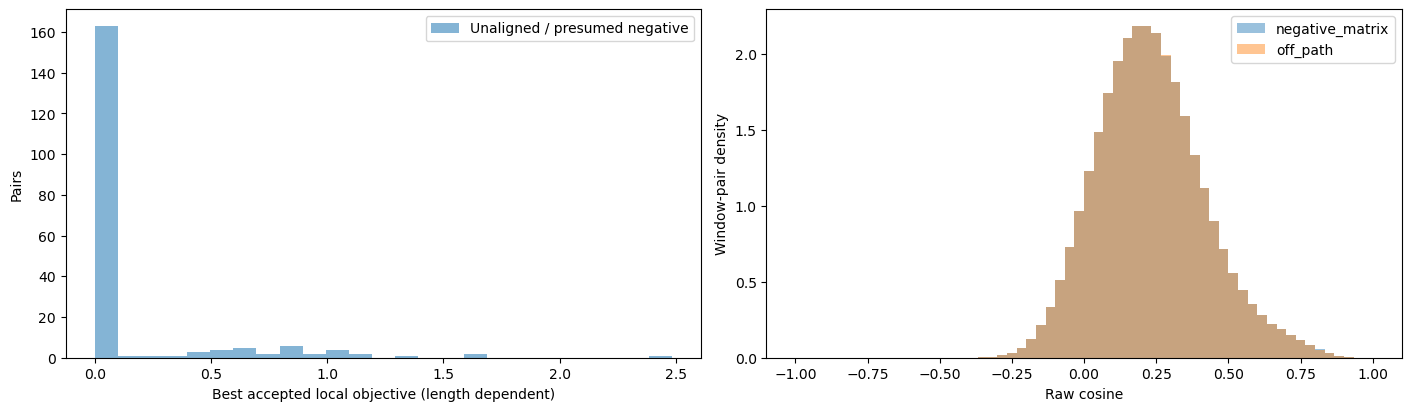

,count,mean,std,median,q25,q75
positive_path,0.0,NaN,NaN,NaN,NaN,NaN
negative_matrix,785862.0,0.231131,0.187869,0.219901,0.100734,0.346979
off_path,785653.0,0.230994,0.187700,0.219839,0.100697,0.346851


Manifest-label discrimination: {'status': 'unavailable', 'reason': 'both positive and negative labels required', 'count': 0}
Including presumed negatives (separate diagnostic): {'status': 'unavailable', 'reason': 'both positive and negative labels required', 'count': 198}


In [21]:
if population is not None:
    figure = plot_distributions(population)
    display(figure); plt.close(figure)
    display(pd.DataFrame(population["distribution_stats"]).T)
    print("Manifest-label discrimination:", discrimination_metrics(
        population["rows"], decision_threshold=PAIR_DECISION_THRESHOLD))
    if any(r["constructed_negative"] for r in population["rows"]):
        print("Including presumed negatives (separate diagnostic):", discrimination_metrics(
            population["rows"], include_constructed=True, decision_threshold=PAIR_DECISION_THRESHOLD))

## 7. Localization metrics and annotation availability
Source-size masks are scored only after prediction. Mask geometry mismatches raise; no GT resizing is allowed. Optional `ANNOTATION_MANIFEST` accepts existing project `alignment_mask_path` fields, or `alignment_mask_meta.A/B.intervals_x` with exact `mask_size=[width,height]`. Those intervals are explicit alignment supervision; a preprocessing `bbox` or XML line envelope is **never** treated as aligned content.

Pixel IoU, Dice/F1, precision and recall are separate for both lines. Boundary errors compare outer horizontal envelopes (unavailable if either mask is empty), not individual disjoint regions. Window GT requires ≥50% of each actual source-mapped footprint to be white. Prediction-positive windows are supported anchors plus explicitly filled tiny gaps. Overlapping pixel footprints do not automatically add adjacent window positives.

Both-empty masks have IoU=1 and undefined-denominator precision/recall/F1 reported as 0, matching the existing evaluator. Region overlap is not character-level accuracy. Any annotation derived from text/box heuristics must retain its provenance.

In [22]:
if population is not None:
    spatial = aggregate_summary(population)["localization"]
    display(pd.DataFrame(spatial).T if spatial else
            "Ground-truth localization metrics unavailable for this dataset.")

'Ground-truth localization metrics unavailable for this dataset.'

## 8. Test-only retrieval
For each eligible A query: all known relevant B partners plus at most `RETRIEVAL_NEGATIVES` seeded distractors. Known provided negatives are eligible, as are presumed other-group candidates; unannotated shared content remains possible. All candidates stay in the saved test split. Report query count and candidate identities, Top-1, Top-5 (only pools ≥5), and MRR.

Ties use **pessimistic rank**, putting tied irrelevant candidates ahead of relevant ones. An all-zero score space cannot win because the true pair was listed first. This is sampled-candidate retrieval, not exhaustive corpus retrieval.

In [23]:
retrieval = retrieval_metrics(session, REPRESENTATION, RETRIEVAL_NEGATIVES, RETRIEVAL_MAX_QUERIES) if RUN_RETRIEVAL else None
if retrieval is not None:
    display({k: v for k, v in retrieval.items() if k != "rows"})
    if retrieval.get("rows"):
        display(pd.DataFrame(retrieval["rows"]).head())

Test retrieval: 0it [00:00, ?it/s]


{'status': 'unavailable',
 'reason': 'no queries with both known positives and eligible distractors'}

## 9. Feature norms and collapse diagnostics
Sample lines/windows reproducibly with `RANDOM_SEED`. Report local/context/fused norms, finite values, feature-wise standard deviation and pairwise cosine statistics. Fused norms should be approximately 1. High cosine or low variance is a warning to inspect unrelated lines, not a standalone collapse diagnosis.

In [24]:
diagnostics = feature_diagnostics(session, FEATURE_MAX_LINES, FEATURE_MAX_WINDOWS) if RUN_FEATURE_DIAGNOSTICS else None
if diagnostics is not None:
    display(pd.DataFrame(diagnostics["representations"]).T)
    for name, values in diagnostics["representations"].items():
        for warning in values.get("warnings", []):
            print(name.upper(), "WARNING:", warning)
    print(diagnostics["note"])

,status,windows,lines,norm_mean,norm_std,norm_min,norm_max,finite,feature_std_mean,pairwise_cosine,warnings
local,available,1024,100,8.121944,2.609422,3.412032,21.336939,True,0.692865,"{'count': 523776, 'mean': 0.1627474163218362, ...",[]
context,available,1024,100,11.319244,0.002471,11.31308,11.326241,True,0.820904,"{'count': 523776, 'mean': 0.31666798013628145,...",[]
fused,available,1024,100,1.0,0.0,1.0,1.0,True,0.076484,"{'count': 523776, 'mean': 0.2394163100175432, ...",[]


Seeded window sample; pairwise statistics include within-line and cross-line pairs, not a collapse verdict.


## 10. Failure analysis and automatic best/worst examples
Rank positives by score and, where available, localization IoU/Dice. Rank negatives by strongest accepted objective. Empty predictions stay in these tables. Low score is a diagnostic failure candidate, not proof that a dataset label is correct. `TOP_K` controls table sizes; enable `SHOW_FAILURE_FIGURES` to use the same comprehensive plot for automatically selected examples.

In [25]:
tables = failure_tables(population["rows"], TOP_K) if population is not None else {}
by_id = {p["sample_id"]: p for p in session.pairs}
for name, table in tables.items():
    print(name.replace("_", " ").upper())
    display(table)
    if SHOW_FAILURE_FIGURES:
        show_pairs([by_id[sid] for sid in table["sample_id"]])

STRONGEST ALIGNED


,sample_id,label,constructed_negative,pair_score,mask_coverage_a,mask_coverage_b,path_length,pair_mean_iou,pair_mean_dice


WEAKEST ALIGNED


,sample_id,label,constructed_negative,pair_score,mask_coverage_a,mask_coverage_b,path_length,pair_mean_iou,pair_mean_dice


STRONGEST NEGATIVE


,sample_id,label,constructed_negative,pair_score,mask_coverage_a,mask_coverage_b,path_length,pair_mean_iou,pair_mean_dice
0,constructed:717ab570af9c358b4e21,constructed_negative,True,2.484158,0.209231,0.199537,12,None,None
1,constructed:0b1da0031caf1bc656cd,constructed_negative,True,1.672792,0.137200,0.142857,8,None,None
2,constructed:33ed1bc10a0a6a0cdde8,constructed_negative,True,1.670630,0.118700,0.122008,8,None,None
3,constructed:46488b2ac14ff2b1c833,constructed_negative,True,1.305807,0.136431,0.128500,8,None,None
4,constructed:e1b076cdff4ae45a1cd1,constructed_negative,True,1.181577,0.104615,0.101220,6,None,None


WORST LOCALIZATION


,sample_id,label,constructed_negative,pair_score,mask_coverage_a,mask_coverage_b,path_length,pair_mean_iou,pair_mean_dice


## 11. Optional image-to-text DTW diagnostic (separate)
This section alone reads the line's own transcript. It uses the saved alphabet-NLL competition, DTW prior, transitions and T+L normalization. It never feeds image-to-image matching or predicted masks. A hard path and low training loss do not independently establish letter localization.

In [26]:
if RUN_TEXT_DTW_DIAGNOSTIC:
    for pair in aligned_samples[:1] or unaligned_samples[:1]:
        diagnostic = text_dtw_diagnostic(session, pair["sides"][0])
        if diagnostic["status"] == "available":
            figure, axes = plt.subplots(1, 2, figsize=(15, 5))
            for ax, key in zip(axes, ("cosine", "costs")):
                heat = ax.imshow(diagnostic[key], origin="lower", aspect="auto",
                                 **({"vmin": -1, "vmax": 1} if key == "cosine" else {}))
                a, b = zip(*diagnostic["path"]); ax.plot(b, a, "r-", lw=1)
                ax.set(title=key, xlabel="Transcript letter index", ylabel="RTL logical windows")
                figure.colorbar(heat, ax=ax)
            display(figure); plt.close(figure)
            print({k: diagnostic[k] for k in ("positive_dtw", "hard_objective", "normalization")})
        else:
            print(diagnostic)

## 12. Aggregate evaluation summary
Only supported localization and retrieval metrics are populated; missing supervision stays unavailable. Main comparisons are corresponding versus unrelated visual representations and spatial localization when annotated. Improving online training loss is not proof of either.

In [27]:
summary = aggregate_summary(population, retrieval, PAIR_DECISION_THRESHOLD) if population is not None else {
    "status": "qualitative only; full quantitative evaluation disabled", "split": SPLIT}
display(pd.json_normalize(summary, sep=".").T)
print("No threshold was selected using test labels.")

,0
split,test
population,all eligible saved-split pairs
evaluated_pairs,198
aligned_pairs,0
unaligned_pairs,198
...,...
unaligned_mask_coverage_b.mean,0.017908
unaligned_mask_coverage_b.std,0.040167
unaligned_mask_coverage_b.median,0.0
unaligned_mask_coverage_b.q25,0.0


No threshold was selected using test labels.


## 13. Save reviewable results
Each run creates a unique directory below `Results/Evaluation/<checkpoint-run>/`. JSON records the checkpoint hash/config, split identity, settings, counts, provenance and limitations. CSV stores pair metrics. The random selections are saved separately. Qualitative artifacts include raw cosine/reward matrices, binary masks, correspondence coordinates, rejection reasons and comprehensive figures. No dataset/checkpoint file is written.

In [28]:
OUTPUT = None
if SAVE_RESULTS and population is not None:
    OUTPUT = save_results(session, population, summary, aligned_samples, unaligned_samples,
                          project_path(RESULTS_ROOT), diagnostics)
    if SAVE_FIGURES:
        for label, samples in (("aligned", aligned_samples), ("unaligned", unaligned_samples)):
            for pair in samples:
                result = qualitative_results.get(pair["sample_id"]) or session.evaluate_pair(pair, REPRESENTATION)
                name = hashlib.sha256(pair["sample_id"].encode()).hexdigest()[:16]
                directory = OUTPUT / label / name
                save_pair_artifacts(session, result, directory)
                figure = plot_pair_alignment(session, result)
                figure.savefig(directory / "comprehensive.png", dpi=110)
                plt.close(figure)
        figure = plot_distributions(population)
        figure.savefig(OUTPUT / "score_cosine_distributions.png", dpi=130)
        plt.close(figure)
    print("Saved:", OUTPUT)
else:
    print("Results not saved (SAVE_RESULTS=False or full quantitative section disabled).")

Saved: /Users/ahmedmas/Desktop/AlignmentProject/Results/Evaluation/real_20260924_222148/test_43ca107f8630


## Interpretation and next steps
Inspect random originals/masks first, then raw cosine and accepted anchors, then the strongest negative and weakest positive examples. Compare local/context/fused on the same images. Calibrate reward/support thresholds on a separately labelled validation population before running a final test. If saved membership yields no positive test pairs, acquire evaluation annotations within the held-out population or explicitly report a separate in-sample diagnostic; do not silently replace the checkpoint split. Ground-truth region masks would add localization evidence, while character-level claims require character annotations.